In [1]:
#################################
# 1. IMPORTS & CONFIG
#################################
import os
import gc
import cv2
import torch
import random
import numpy as np
import pandas as pd

from torchvision import models

from glob import glob
from torch import nn
from tqdm import tqdm
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
import torchvision
import torchvision.transforms as T
from sklearn.metrics import f1_score
from PIL import Image  # في بداية الملف
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

In [2]:
# التحقق من توفر الـ GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🖥️ Using device:", device)

# إذا كان هناك GPU متاح، اطبع اسمه
if device.type == "cuda":
    print("✅ GPU name:", torch.cuda.get_device_name(0))
    print("✅ GPU memory allocated:", round(torch.cuda.memory_allocated(0) / 1024**3, 2), "GB")
    print("✅ GPU memory reserved:", round(torch.cuda.memory_reserved(0) / 1024**3, 2), "GB")
else:
    print("⚠️ GPU not available. Using CPU instead.")

🖥️ Using device: cuda
✅ GPU name: Tesla P100-PCIE-16GB
✅ GPU memory allocated: 0.0 GB
✅ GPU memory reserved: 0.0 GB


In [3]:
#################################
# 2. BASIC SETTINGS
#################################
class CFG:
    seed = 42
    n_splits = 5          # نُبقيه كما هو لأنك تستخدم K-Fold
    epochs = 10            # تقليل عدد الـ Epochs لتسريع التجربة (3 فقط كبداية)
    train_bs = 8          # تقليل Batch Size ليتناسب مع 100 صورة (ويوفر الذاكرة)
    valid_bs = 16         # نفس السبب — لا حاجة لحجم كبير
    lr = 1e-3             # نتركه كما هو (معدل تعلم ثابت كبداية)
    num_workers = 0       # لتفادي مشاكل تحميل البيانات على Google Colab
    img_size = 224        # نتركه كما هو (مناسب لـ EfficientNet-B0)
    device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

In [4]:
#################################
# 3. LOAD DATA
#################################
train_df = pd.read_csv(r"/kaggle/input/sheep-classification-challenge-2025/Sheep Classification Images/train_labels.csv")
train_df["path"] = "/kaggle/input/sheep-classification-challenge-2025/Sheep Classification Images/train//" + train_df["filename"]
train_df.drop("filename", axis=1, inplace=True)
train_df = train_df[["path","label"]]
#train_df = train_df.iloc[:100]  # يحتفظ فقط بأول 100 صف

print("Train Shape:", train_df.shape)
print(train_df.head())

# Map string labels to integer indices
label_mapping = {
    "Harri":        0,
    "Najdi":     1,
    "Naeimi":     2,
    "Goat":  3,
    "Sawakni":     4,
    "Barbari":      5,
    "Roman":      6
}
train_df["label_idx"] = train_df["label"].map(label_mapping)

Train Shape: (682, 2)
                                                path   label
0  /kaggle/input/sheep-classification-challenge-2...  Naeimi
1  /kaggle/input/sheep-classification-challenge-2...    Goat
2  /kaggle/input/sheep-classification-challenge-2...   Roman
3  /kaggle/input/sheep-classification-challenge-2...   Roman
4  /kaggle/input/sheep-classification-challenge-2...  Naeimi


📊 عدد الصور: 682
📐 أصغر حجم: {'width': 36, 'height': 49}
📏 أكبر حجم: {'width': 900, 'height': 1800}
📌 أكثر المقاسات تكرارًا: [((225, 225), 66), ((140, 140), 55), ((900, 1200), 21), ((259, 194), 7), ((275, 183), 7)]
📉 عدد الصور التي أبعادها أصغر من 300x300: 492


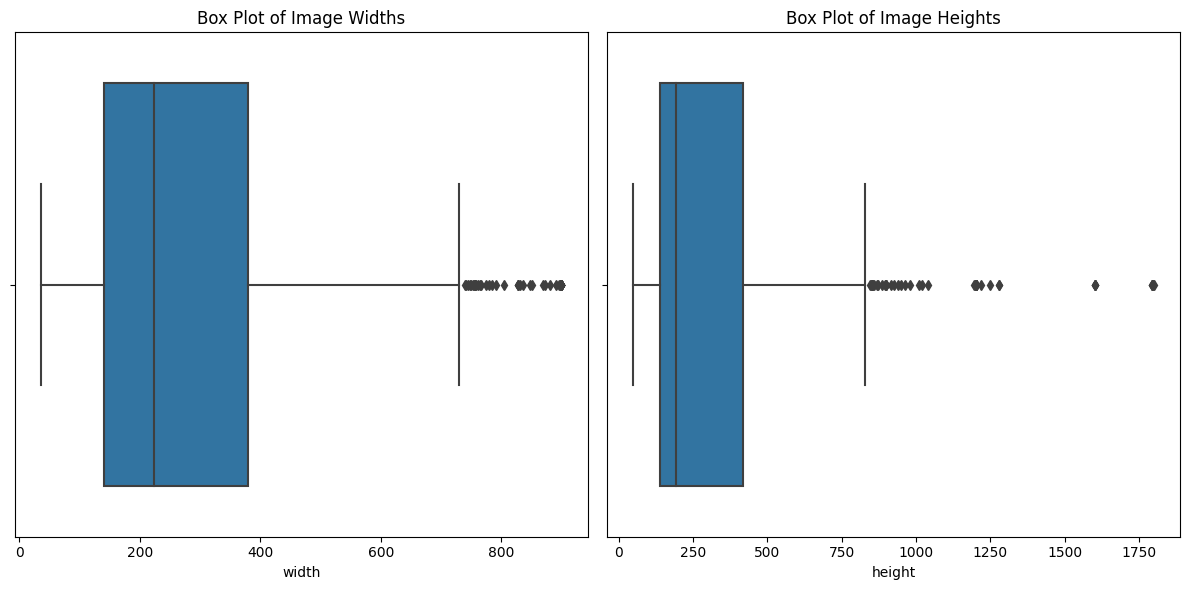

In [5]:
from collections import Counter

# نحفظ المقاسات هنا
sizes = []
# افحص كل صورة في مسارات train_df
for path in train_df["path"]:
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        sizes.append((w, h))

# تحويل إلى DataFrame
size_df = pd.DataFrame(sizes, columns=["width", "height"])

# إحصائيات
size_counts = Counter(sizes)
most_common = size_counts.most_common(5)

print("📊 عدد الصور:", len(sizes))
print("📐 أصغر حجم:", size_df.min().to_dict())
print("📏 أكبر حجم:", size_df.max().to_dict())
print("📌 أكثر المقاسات تكرارًا:", most_common)
# حساب الصور التي عرضها أو طولها أقل من 300 بكسل
small_images = size_df[(size_df["width"] < 300) | (size_df["height"] < 300)]
# طباعة عددها
print(f"📉 عدد الصور التي أبعادها أصغر من 300x300:", len(small_images))

# رسم Box Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=size_df["width"])
plt.title("Box Plot of Image Widths")

plt.subplot(1, 2, 2)
sns.boxplot(x=size_df["height"])
plt.title("Box Plot of Image Heights")

plt.tight_layout()
plt.show()

In [6]:
classes = train_df["label"].unique()
print("🟢 Classes:", classes)
print("🔢 Number of classes:", len(classes))
print(train_df["label"].value_counts())

🟢 Classes: ['Naeimi' 'Goat' 'Roman' 'Harri' 'Sawakni' 'Barbari' 'Najdi']
🔢 Number of classes: 7
label
Naeimi     255
Goat       107
Sawakni     80
Roman       72
Najdi       71
Harri       62
Barbari     35
Name: count, dtype: int64


In [7]:
# أخذ حتى 250 صورة من كل كلاس (إذا كانت متوفرة)
balanced_df = train_df.groupby("label").apply(
    lambda x: x.sample(n=min(250, len(x)), random_state=CFG.seed)
).reset_index(drop=True)

# إعادة ترتيب الأعمدة
balanced_df = balanced_df[["path", "label", "label_idx"]]

# التأكد من النتيجة
print(balanced_df["label"].value_counts())
print("Total samples:", len(balanced_df))


#################################
# 4. K-FOLD Split
#################################
balanced_df["fold"] = -1
kf = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.seed)

for fold_number, (tr_idx, val_idx) in enumerate(kf.split(balanced_df, balanced_df["label"])):
    balanced_df.loc[val_idx, "fold"] = fold_number

print(balanced_df.groupby("fold").size())

label
Naeimi     250
Goat       107
Sawakni     80
Roman       72
Najdi       71
Harri       62
Barbari     35
Name: count, dtype: int64
Total samples: 677
fold
0    136
1    136
2    135
3    135
4    135
dtype: int64


In [8]:
# توزيع الصور حسب الفئة
label_counts = balanced_df["label"].value_counts()

# تعريف الدالة التي تحدد نوع الـ augmentation
def assign_aug(label):
    count = label_counts[label]
    if count <= 70:  # الكلاسات الأقل (Barbari, Harri)
        return "strong_aug"
    elif 70 < count <= 110:  # الكلاسات المتوسطة (Najdi, Roman, Sawakni, Goat)
        return "basic_aug"
    else:  # Naeimi أو أي فئة عددها كبير
        return "none"

# تطبيق الدالة وإضافة العمود
train_df["aug"] = train_df["label"].apply(assign_aug)


In [9]:
#################################
# 5. DATASET & TRANSFORMS
#################################

# Augmentations حسب نوع الكلاس
resize_only = T.Compose([
    T.Resize((300, 300)),
    T.ToTensor()
])

basic_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    
    T.Resize((300, 300)),
    T.ToTensor()
])

strong_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomResizedCrop(size=(300, 300), scale=(0.8, 1.0)),
    
    T.Resize((300, 300)),
    T.ToTensor()
])

# نفس الشيء للـ Validation
valid_transforms = T.Compose([
    T.Resize((300, 300)),  # ✅ ضروري
    T.ToTensor()           # ✅ ضروري
])

In [10]:
class SheepDataset(Dataset):
    def __init__(self, df, mode="train"):
        self.df = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        image_path = row["path"]
        label_idx = row["label_idx"] if "label_idx" in row else None
        aug_type = row.get("aug", "none")  # نحصل على نوع التحويل

        # قراءة الصورة وتحويلها إلى RGB ثم PIL
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        # اختيار التحويل المناسب بناءً على وضع التشغيل ونوع التحويل
        if self.mode == "train":
            if aug_type == "strong_aug":
                image = strong_aug(image)
            elif aug_type == "basic_aug":
                image = basic_aug(image)
            else:
                image = resize_only(image)
        else:
            image = valid_transforms(image)

        if self.mode != "test":
            return image, label_idx
        else:
            return image

In [11]:
#################################
# 6. MODEL DEFINITION (EffNet-B0)
#################################
# We'll modify the final layer for the number of classes we have (7).
def get_model(num_classes=7, pretrained=True):
    model = torchvision.models.efficientnet_b3(pretrained=pretrained)
    model.classifier[1] = nn.Linear(1536, num_classes)
    return model

In [12]:
#################################
# 7. TRAIN & VALID FUNCTIONS
#################################
def train_one_epoch(model, optimizer, dataloader, device, criterion):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(dataloader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    epoch_loss = total_loss / len(dataloader.dataset)
    return epoch_loss

def valid_one_epoch(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Validating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(dataloader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, f1

In [13]:
#################################
# 8. K-FOLD TRAINING LOOP
#################################
def run_training(fold):
    print(f"========== Fold: {fold} ==========")

    # Split
    train_data = balanced_df[balanced_df["fold"] != fold].reset_index(drop=True)
    valid_data = balanced_df[balanced_df["fold"] == fold].reset_index(drop=True)

    # Datasets
    train_dataset = SheepDataset(train_data, mode="train")
    valid_dataset = SheepDataset(valid_data, mode="valid")

    # Loaders
    train_loader = DataLoader(train_dataset, batch_size=CFG.train_bs,
                              shuffle=True, num_workers=CFG.num_workers)
    valid_loader = DataLoader(valid_dataset, batch_size=CFG.valid_bs,
                              shuffle=False, num_workers=CFG.num_workers)

    # Model, Optimizer, Loss
    model = get_model(num_classes=len(label_mapping), pretrained=True)
    model.to(CFG.device)
    print("🔍 Model is on device:", next(model.parameters()).device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)

    best_f1 = 0.0
    for epoch in range(CFG.epochs):
        print(f"Fold {fold} | Epoch {epoch+1}/{CFG.epochs}")

        train_loss = train_one_epoch(model, optimizer, train_loader, CFG.device, criterion)
        valid_loss, valid_f1 = valid_one_epoch(model, valid_loader, CFG.device, criterion)

        print(f"  [Train Loss: {train_loss:.4f}]  [Valid Loss: {valid_loss:.4f}]  [Valid F1 Score: {valid_f1:.4f}]")

        if valid_f1 > best_f1:
            best_f1 = valid_f1
            save_path = f"effb0_fold_{fold}.pth"
            torch.save(model.state_dict(), save_path)
            print(f"  --> Model saved to {save_path}")

    print(f"Fold {fold} best F1 Score: {best_f1:.4f}\n")


In [14]:
for fold in range(CFG.n_splits):
    run_training(fold)

========== Fold: 0 ==========


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 123MB/s]


🔍 Model is on device: cuda:0
Fold 0 | Epoch 1/10


  [Train Loss: 0.8751]  [Valid Loss: 0.4705]  [Valid F1 Score: 0.7765]
  --> Model saved to effb0_fold_0.pth
Fold 0 | Epoch 2/10


  [Train Loss: 0.4470]  [Valid Loss: 0.4874]  [Valid F1 Score: 0.8505]
  --> Model saved to effb0_fold_0.pth
Fold 0 | Epoch 3/10


...

  [Train Loss: 0.1689]  [Valid Loss: 0.1680]  [Valid F1 Score: 0.9420]
  --> Model saved to effb0_fold_4.pth
Fold 4 | Epoch 7/10


  [Train Loss: 0.0989]  [Valid Loss: 0.2294]  [Valid F1 Score: 0.9053]
Fold 4 | Epoch 8/10


  [Train Loss: 0.0741]  [Valid Loss: 0.3055]  [Valid F1 Score: 0.8956]
Fold 4 | Epoch 9/10


  [Train Loss: 0.1147]  [Valid Loss: 0.3565]  [Valid F1 Score: 0.8865]
Fold 4 | Epoch 10/10


  [Train Loss: 0.1737]  [Valid Loss: 0.2069]  [Valid F1 Score: 0.9320]
Fold 4 best F1 Score: 0.9420



In [15]:

# تأكد أن لديك هذا من قبل

# ===== إعدادات عامة =====
device = CFG.device
NUM_FOLDS = CFG.n_splits
BATCH_SIZE = CFG.valid_bs

# ماب الكلاسات
idx_to_label = {
    0: "Harri",
    1: "Najdi",
    2: "Naeimi",
    3: "Goat",
    4: "Sawakni",
    5: "Barbari",
    6: "Roman"
}


# ===============================
# 2. إعداد test_df
test_dir = "/kaggle/input/sheep-classification-challenge-2025/Sheep Classification Images/test"  # ضع المسار المناسب هنا
# إنشاء DataFrame يحتوي على مسارات الصور
test_files = sorted([f for f in os.listdir(test_dir) if f.endswith(".jpg")])
test_paths = [os.path.join(test_dir, f) for f in test_files]
test_df = pd.DataFrame({
    "filename": test_files,
    "path": test_paths
})

# ===============================
# 3. إعداد الداتاست واللودر
# إعداد داتا لوودر للاختبار
test_dataset = SheepDataset(test_df, mode="test")
test_loader = DataLoader(test_dataset, batch_size=CFG.valid_bs, shuffle=False, num_workers=CFG.num_workers)

# ===============================
# 4. تنبؤ باستخدام جميع الـ Folds
all_predictions = []

print("\n🔍 Generating test predictions...")
for fold in range(NUM_FOLDS):
    model_path = f"effb0_fold_{fold}.pth"
    if not os.path.exists(model_path):
        print(f"❌ Model for fold {fold} not found, skipping.")
        continue

    print(f"✅ Fold {fold + 1}/{NUM_FOLDS}")
    model = get_model(num_classes=7, pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    fold_preds = []
    with torch.no_grad():
        for imgs in tqdm(test_loader, desc=f"Fold {fold+1} Inference"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            fold_preds.append(probs)

    fold_preds = np.concatenate(fold_preds, axis=0)
    all_predictions.append(fold_preds)

    # تنظيف
    del model
    gc.collect()
    torch.cuda.empty_cache()

# ===============================
# 5. تجميع التوقعات النهائية
avg_predictions = np.mean(all_predictions, axis=0)
final_indices = np.argmax(avg_predictions, axis=1)
final_labels = [idx_to_label[idx] for idx in final_indices]

# ===============================
# 6. إنشاء ملف submission
submission_df = pd.DataFrame({
    "filename": test_df["filename"],
    "label": final_labels
})
submission_df.to_csv("submission.csv", index=False)
print("\n📁 Saved submission.csv!")
print(submission_df.head())

# ===============================
# 7. حفظ ملف الاحتمالات
prob_df = pd.DataFrame({
    "filename": test_df["filename"],
    "pred_label": final_labels
})
for i, class_name in idx_to_label.items():
    prob_df[f"prob_{class_name}"] = avg_predictions[:, i]

prob_df.to_csv("test_predictions_with_probs.csv", index=False)
print("📁 Saved test_predictions_with_probs.csv!")


🔍 Generating test predictions...
✅ Fold 1/5


Fold 1 Inference: 100%|██████████| 9/9 [00:01<00:00,  4.84it/s]


✅ Fold 2/5


Fold 2 Inference: 100%|██████████| 9/9 [00:01<00:00,  6.76it/s]


✅ Fold 3/5


...

✅ Fold 4/5


Fold 4 Inference: 100%|██████████| 9/9 [00:01<00:00,  6.79it/s]


✅ Fold 5/5


Fold 5 Inference: 100%|██████████| 9/9 [00:01<00:00,  6.80it/s]



📁 Saved submission.csv!
       filename    label
0  0306fa89.jpg  Barbari
1  0345e3ca.jpg    Roman
2  0551a473.jpg  Sawakni
3  06e1783d.jpg   Naeimi
4  08b9981b.jpg  Barbari
📁 Saved test_predictions_with_probs.csv!
